In [ ]:
# Install if not already
!pip install inference

from inference_sdk import InferenceHTTPClient
import cv2
import matplotlib.pyplot as plt

# === Step 1: Initialize Client ===
# import the inference-sdk
# Install Roboflow Inference SDK
!pip install inference

from inference_sdk import InferenceHTTPClient
from google.colab import files
import os

# Define model info with their own API keys and model IDs
models = {
    "cassava": {
        "model_id": "cassava-disease-zqjxb-rl2r2/1",
        "api_url": "https://serverless.roboflow.com",  # or detect.roboflow.com
        "api_key": "xg0E2Az768qCexdziw72",
        "solutions": {
            "cbb": "Cassava Bacterial Blight: Use resistant varieties.",
            "cmd": "Cassava Mosaic Disease: Remove infected plants.",
            "cgm": "Cassava Green Mite: Apply miticides or use biocontrol.",
            "cbsd": "Cassava Brown Streak Disease: Use virus-free cuttings.",
            "healthy": "Healthy cassava plant!"
        }
    },
    "maize": {
        "model_id": "maize-disease-w9ggw/2",
        "api_url": "https://serverless.roboflow.com",
        "api_key": "HjAbvCwdDSoHCJzZBFIR",
        "solutions": {
           "Anthracnose_leaf_blight": "Remove infected debris and rotate crops.",
        "Bactarial_leaf_streak_of_corn": "Use disease-free seeds and resistant hybrids.",
        "Banded_leaf_and_sheath_blight": "Avoid waterlogging and use recommended fungicides.",
        "Brown_spot": "Apply nitrogen-rich fertilizers and ensure good drainage.",
        "Common_rust": "Use resistant varieties and apply fungicides if needed.",
        "Fall_Armyworm": "Apply biopesticides or neem-based products; monitor regularly.",
        "Gray_leaf_spot": "Rotate crops, avoid high planting density.",
        "Northern_leaf_blight": "Use fungicide and resistant seed varieties.",
        "Southern_leaf_Blight": "Practice crop rotation and ensure clean field management."
        }
    },
    "rice": {
        "model_id": "rice-disease-vahwz-6b2ii/1",
        "api_url": "https://serverless.roboflow.com",
        "api_key": "HjAbvCwdDSoHCJzZBFIR",
        "solutions": {
           "Bacterial Leaf Blight Disease or Bacterial Blight Disease": "Use certified seeds and avoid excessive nitrogen.",
        "Bacterial Leaf Streak Disease": "Plant resistant varieties and use appropriate field sanitation.",
        "Brown Spot Disease": "Apply potash fertilizers and practice good water management.",
        "Dirty Panicle Disease": "Ensure clean seeds and use fungicides before heading.",
        "Grassy Stunt Disease": "Control brown planthopper and use resistant varieties.",
        "Narrow Brown Spot Disease": "Manage nitrogen levels and improve drainage.",
        "Rice Blast Disease": "Apply balanced fertilizers and use fungicides when necessary.",
        "Rice Ragged Stunt Disease": "Control vectors like brown planthopper; remove infected plants.",
        "Rice Tungro Disease or Yellow Orange Leaf Disease": "Use vector-resistant rice and early planting.",
        "Sheath blight Disease": "Avoid dense planting and use resistant rice strains."
        }
    }
}



Enter crop type (cassava / maize / rice): rice


Saving rice_disease.jpg to rice_disease (5).jpg

📌 Prediction Results:
- BROWN SPOT DISEASE: Apply potash fertilizers and practice good water management.
Prediction without bounding box: Brown Spot Disease (Confidence: 0.92)


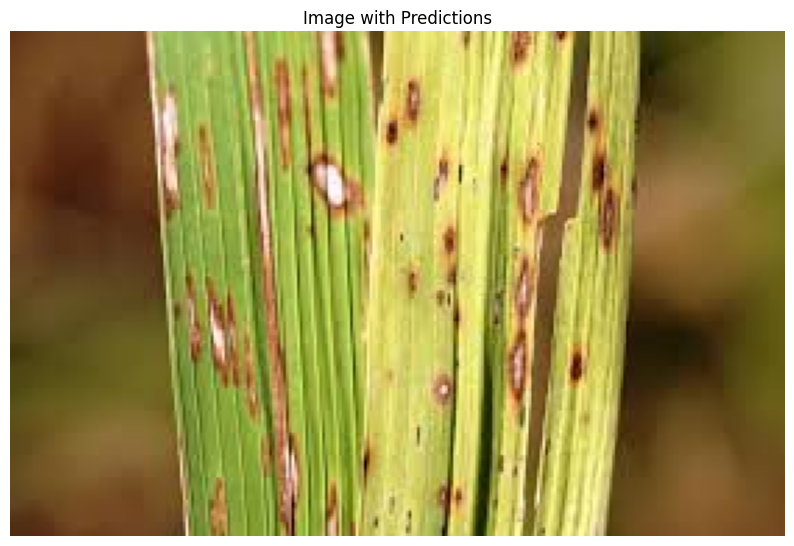

In [ ]:
# Ask user to choose a crop
crop = input("Enter crop type (cassava / maize / rice): ").strip().lower()

if crop not in models:
    print("❌ Invalid crop selected.")
else:
    # Upload image
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]

    # Set up model details
    model_info = models[crop]

    # Initialize the specific client
    client = InferenceHTTPClient(
        api_url=model_info["api_url"],
        api_key=model_info["api_key"]
    )

    # Make prediction
    result = client.infer(image_path, model_id=model_info["model_id"])
    predictions = result["predictions"]

    print("\n📌 Prediction Results:")
    if predictions:
        # Load the original image here within the successful prediction block
        import cv2
        import matplotlib.pyplot as plt

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for pred in predictions:
            label = pred["class"]
            solution = model_info["solutions"].get(label, "No solution available.")
            print(f"- {label.upper()}: {solution}")

            if all(key in pred for key in ["x", "y", "width", "height"]):
                # Get bounding box coordinates
                x1 = int(pred["x"] - pred["width"] / 2)
                y1 = int(pred["y"] - pred["height"] / 2)
                x2 = int(pred["x"] + pred["width"] / 2)
                y2 = int(pred["y"] + pred["height"] / 2)

                # Draw bounding box
                color = (255, 0, 0)  # Red color for bounding box
                thickness = 2
                cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

                # Put label and confidence
                confidence = pred["confidence"]
                text = f"{label}: {confidence:.2f}"
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.5
                text_thickness = 1
                text_size, _ = cv2.getTextSize(text, font, font_scale, text_thickness)
                text_x = x1
                text_y = y1 - 10 if y1 - 10 > 10 else y1 + 10
                cv2.putText(img, text, (text_x, text_y), font, font_scale, color, text_thickness)
            else:
                # Handle predictions without bounding box information (e.g., classification only)
                label = pred["class"]
                confidence = pred["confidence"]
                print(f"Prediction without bounding box: {label} (Confidence: {confidence:.2f})")

        # Display the image with bounding boxes
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Image with Predictions")
        plt.show()
    else:
        print("✅ No issue detected. Healthy crop!")
        # Load and display the original image here if no predictions
        import cv2
        import matplotlib.pyplot as plt
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Original Image (No Detections)")
        plt.show()


🧠 Running Cassava Detection on: /content/cassava.jpg

🔍 Detected: Cassava Bacterial Blight
🧪 Confidence: 0.59
💡 Solution: Use resistant varieties, improve drainage, and destroy infected plants.
- CBB (Confidence: 0.59)

🔍 Detected: Cassava Mosaic Disease
🧪 Confidence: 0.43
💡 Solution: Plant virus-free cuttings, control whiteflies, and use resistant varieties.
- CMD (Confidence: 0.43)


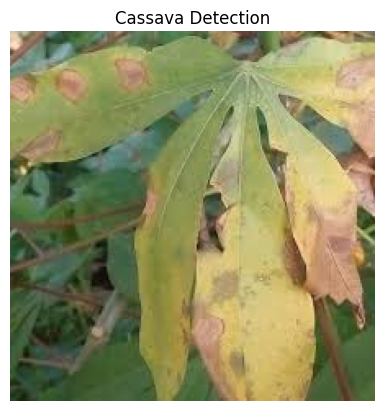

In [ ]:
# === Step 3: Test on Image ===
# Replace this path with the real image you want to test
test_cassava("/content/cassava.jpg")

In [ ]:
# initialize the client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="HjAbvCwdDSoHCJzZBFIR"
)

# infer on a local image
result = CLIENT.infer("YOUR_IMAGE.jpg", model_id="maize-disease-w9ggw/2")

The following code demonstrates how to display the image with bounding boxes and labels from the prediction results.

Prediction without bounding box: Brown Spot Disease (Confidence: 0.92)


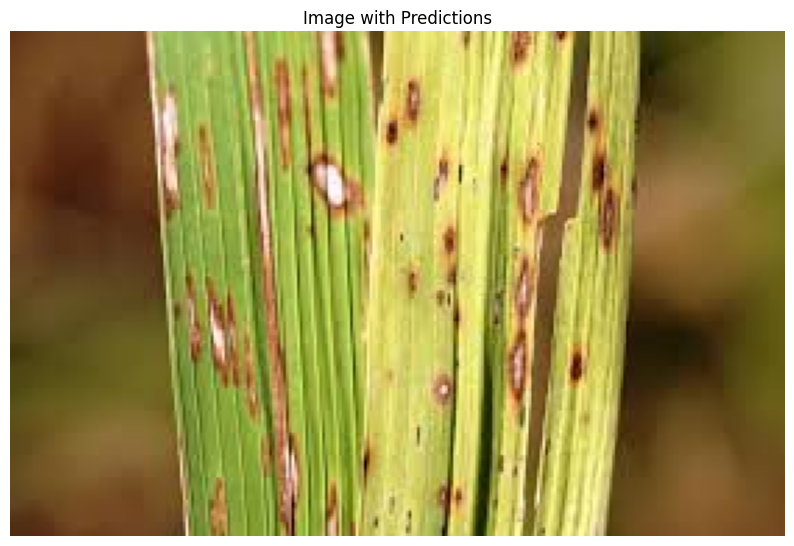

In [ ]:
# Assuming 'result' and 'image_path' are available from the previous step

import cv2
import matplotlib.pyplot as plt

# Load the original image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Check if there are any predictions
if "predictions" in result and result["predictions"]:
    for pred in result["predictions"]:
        # Check if bounding box information exists in the prediction
        if all(key in pred for key in ["x", "y", "width", "height"]):
            # Get bounding box coordinates
            x1 = int(pred["x"] - pred["width"] / 2)
            y1 = int(pred["y"] - pred["height"] / 2)
            x2 = int(pred["x"] + pred["width"] / 2)
            y2 = int(pred["y"] + pred["height"] / 2)

            # Draw bounding box
            color = (255, 0, 0)  # Red color for bounding box
            thickness = 2
            cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

            # Put label and confidence
            label = pred["class"]
            confidence = pred["confidence"]
            text = f"{label}: {confidence:.2f}"
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.5
            text_thickness = 1
            text_size, _ = cv2.getTextSize(text, font, font_scale, text_thickness)
            text_x = x1
            text_y = y1 - 10 if y1 - 10 > 10 else y1 + 10
            cv2.putText(img, text, (text_x, text_y), font, font_scale, color, text_thickness)
        else:
            # Handle predictions without bounding box information (e.g., classification only)
            label = pred["class"]
            confidence = pred["confidence"]
            print(f"Prediction without bounding box: {label} (Confidence: {confidence:.2f})")

    # Display the image with bounding boxes
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Image with Predictions")
    plt.show()

elif "predictions" in result and not result["predictions"]:
    print("✅ No issue detected. Healthy crop!")
    # Display the original image
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Original Image (No Detections)")
    plt.show()

else:
    print("❌ No predictions found in the result.")
    # Display the original image
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Original Image (No Detections)")
    plt.show()

In [ ]:
https://cropdiseaseapp-6weconpunfsvc9duurpxz5.streamlit.app/